In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

import h5py

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def take_abs(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )

    return np.sqrt(mean.T[1]**2 + mean.T[2]**2)


def take_real(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[1]


def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
at=0.2

In [4]:
pwd

'/mnt/baracuda_14/qed3/qed3/src/both_3d'

In [5]:
# f = h5py.File("glue_ylm.hdf5", "r")
# print( f.keys() )
# # f1pt=f['1pt'][()]
# corrs=f['corr'][()][:2500]
# # f.create_dataset("corr", data=corrs, dtype='f' )
# # f.create_dataset("1pt", data=F1pts, dtype='f' )
# f.close()

In [6]:
Nf=2

# gsq="4.000000"
# gsq="2.800000"
gsq="2.000000"
# gsq="0.500000"

# gsq="1.000000"
# gsq="0.500000"
# gsq="0.100000"

# nu0="2.000000"
# nu0="1.500000"
nu0="1.000000"

nu1=nu0 # "1.000000"
# nu1="2.000000"


at="0.200000"
Nt=128
L=1

In [7]:
label="data_Nf"+str(Nf)+"_gsq"+str(gsq)+"at"+str(at)+"nu0"+str(nu0)+"nt"+str(Nt)+"L"+str(L)
# label="data_gsq"+str(gsq)+"at"+str(at)+"nt"+str(Nt)+"L"+str(L)

In [8]:
dir1='/mnt/baracuda_14/qed3/qed3/src/both_3d/'
path = dir1+label

In [9]:
path

'/mnt/baracuda_14/qed3/qed3/src/both_3d/data_Nf2_gsq2.000000at0.200000nu01.000000nt128L1'

In [10]:
files_ = sorted(glob.glob(path+"/F_corr.*"), key=sorted) # @@@ ill ordered
files = np.array(files_)
iconfigs = [ int(fff.split('.')[-1]) for fff in natsorted(files)]
# iconfigs = [ int(fff.split('.')[-1]) for fff in natsorted(files)][170:]

corrs_=[]
F1pts_=[]
for i in iconfigs[10:]:
# for file in natsorted(files)[170:]:
    corr = np.loadtxt( path+"/F_corr."+str(i) )
    corr = (corr[1:int(Nt/2)] + np.flip( corr[int(Nt/2):Nt-1], axis=0 )).T
    # corr = (corr[1:int(Nt/2)]).T
    F1pt = np.loadtxt( path+"/F."+str(i) ) # [0]
    corrs_.append( corr )
    F1pts_.append( F1pt )

corrs = np.array(corrs_)
F1pts = np.array(F1pts_)

# plt.plot( np.mean(corrs, axis=1) )
# jks_.append([igam,jk.mean(),jk.err()])
    
# plt.ylim(0.0045, 0.0046)
plt.show()

In [12]:
corrs.shape

(4430, 100, 63)

In [13]:
corrs.shape

(4430, 100, 63)

In [121]:
nops=10 # 9
nops1=10

nops2=6 # Nf2
nops2=8

nops2=8

tcut=5
dt=1

trebase=1


In [122]:
# nops=6 # 9
# nops1=6

# nops2=4
# tcut=6
# dt=1

# trebase=1


In [123]:
desc="Nf"+str(Nf)+"_gsq"+str(gsq)+"_at"+str(at)+"_nu0"+str(nu0)

In [124]:
opset=np.array([
    [0,0],
    [1,-1],
    [1,0],
    [1,1],
    # [2,-100],
    # [3,-100],
    [2,-2],
    [2,-1],
    [2,0],
    [2,1],
    [2,2],
    # [3,-3],
    # [3,-2],
    # [3,-1],
    [3,0],
    # [3,1],
    # [3,2],
    # [3,3],
])
assert len(opset)==nops

In [125]:
len(opset)

10

In [126]:
def get_II( irow ):
    return np.array([int(np.floor(irow/nops)), irow%nops ])

def get_lmlm( irow ):
    i1, i2 = get_II(irow)
    return np.array( [opset[i1], opset[i2]])

In [127]:
jk = Jackknife( corrs.shape[0], 100 )
jk.set( simple_mean, corrs )
jk.do_it()

In [128]:
corrs.shape

(4430, 100, 63)

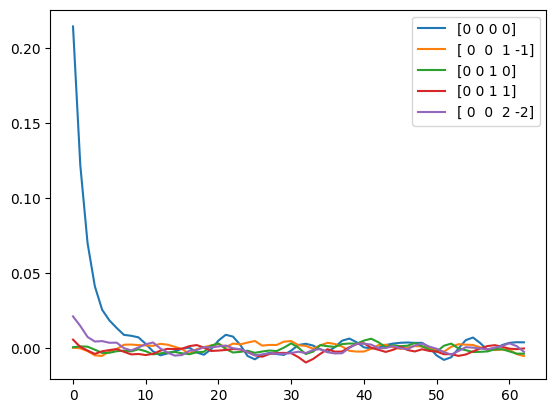

In [129]:
plt.plot( np.mean( corrs, axis=0 )[0], label=str(get_lmlm( 0 ).flatten()) )
plt.plot( np.mean( corrs, axis=0 )[1], label=str(get_lmlm( 1 ).flatten()) )
plt.plot( np.mean( corrs, axis=0 )[2], label=str(get_lmlm( 2 ).flatten()) )
plt.plot( np.mean( corrs, axis=0 )[3], label=str(get_lmlm( 3 ).flatten()) )
plt.plot( np.mean( corrs, axis=0 )[4], label=str(get_lmlm( 4 ).flatten()) )
plt.legend()

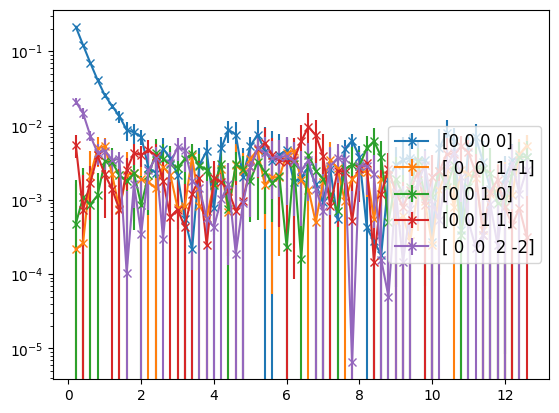

In [130]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(5):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

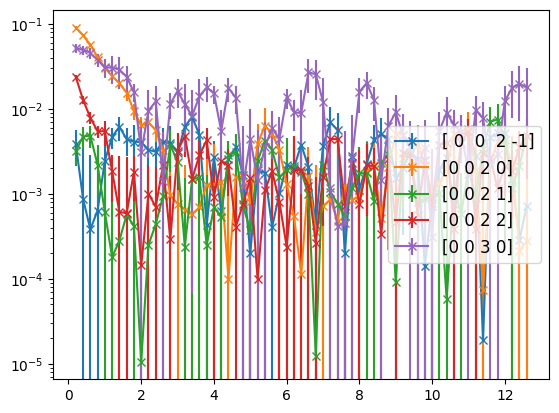

In [131]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(5,10):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

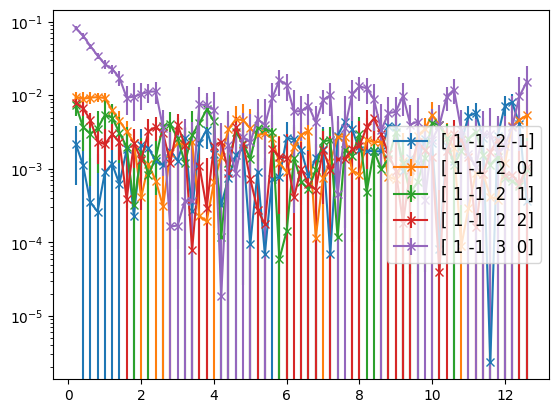

In [132]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(15,20):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

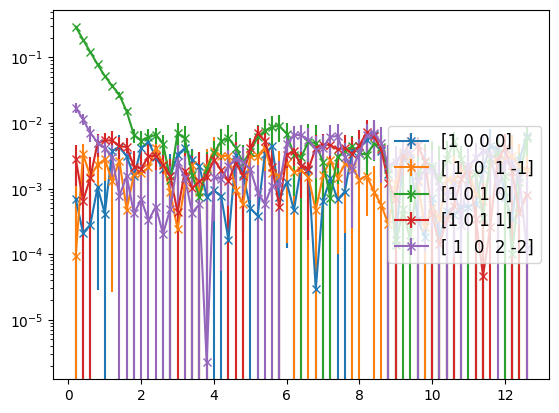

In [133]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(20,25):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

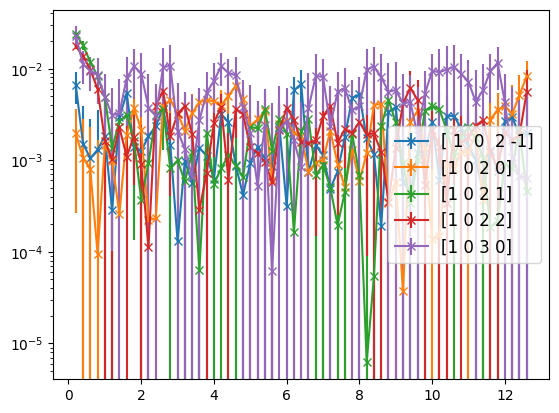

In [134]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(25,30):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

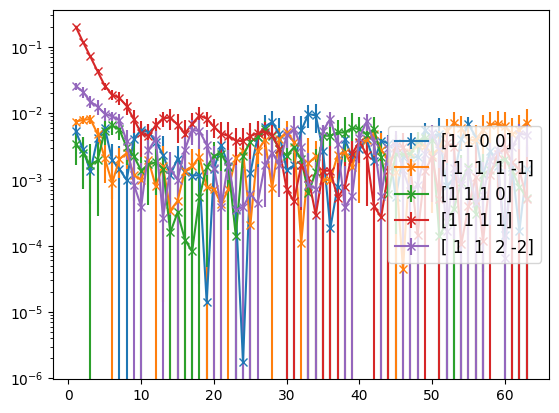

In [135]:
plt.clf()

x = np.arange(1,Nt/2)
float(at)
for i in range(30,35):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(get_lmlm( i ).flatten()) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

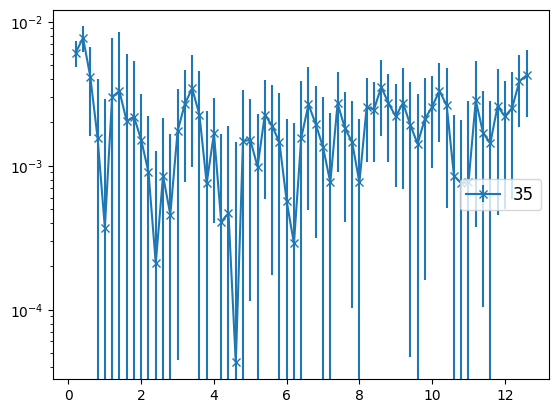

In [136]:
plt.clf()

x = np.arange(1,Nt/2)*float(at)
for i in range(35,36):
    plt.errorbar( x, np.abs(jk.mean()[i]), jk.err()[i], marker='x', label=str(i) )
plt.legend( fontsize=12, loc='right' )
plt.yscale("log")

In [137]:
def zero_noise( est, err ):
    for irow in np.arange( est.shape[0] ):
        lm1, lm2 = get_lmlm( irow )
        # print(lm1, lm2)
        if (lm1[0]==1 and lm2[0]==0) or (lm1[0]==0 and lm2[0]==1): # no mix
            est[irow] = 0.0
            err[irow] = 0.0
            # print(est[irow])
        elif lm1[0]==1 and lm2[0]==1:
            if lm1[1]!=lm2[1]: # no mix
                est[irow] = 0.0
                err[irow] = 0.0
                # print(est[irow])
    return est, err

In [138]:
# plt.clf()

# x = np.arange(1,Nt/2)*float(at)
# for i in range(jk.mean().shape[0]):
#     plt.errorbar( x, est[i], err[i], marker='x', label=str(i) )
# # plt.errorbar( x, jk.mean()[1], jk.err()[1], marker='x' )
# plt.yscale("log")
# plt.legend( ncol=4, fontsize=6, loc='right' )

# plt.savefig( desc+"_glue_all.pdf", bbox_inches="tight" )

In [139]:
jk.mean().shape

(100, 63)

In [140]:
corrs.shape

(4430, 100, 63)

In [141]:
# prod1pt = np.array( np.kron( mean1pt, mean1pt ) )
mean_corr = np.mean(corrs, axis=0)

conn, dummy = zero_noise( mean_corr, mean_corr )
# conn = mean_corr # -prod1pt).T

matC1 = np.array(np.split( conn, nops, axis=0 ))[:nops1,:nops1]
matC = np.transpose(matC1, (-1, 0, -2))
matCT = np.transpose(matC, (0, 2, 1))
matCA = 0.5*(matC+matCT)

In [142]:
at=float(at)

In [143]:
t=trebase
sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
eigval, eigvec = np.linalg.eigh(matM)
Vrebase=eigvec

In [144]:
matCA.shape

(63, 10, 10)

In [145]:
eigvals_ = []
for t in range(1,tcut):
    sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    matMtrunc = (Vrebase.T@matM@Vrebase)[-nops2:,-nops2:]
    # matMtrunc = (matM)[-nops2:,-nops2:]
    eigval, eigvec = np.linalg.eigh(matMtrunc)
    eigvals_.append( eigval )

eigvals = np.array(eigvals_)
-np.log(eigvals)/at

array([[3.16891253, 3.02644106, 2.5985065 , 2.45774354, 2.35642638,
        2.34992247, 2.14748312, 1.57917062],
       [3.51758444, 3.27712507, 2.90457745, 2.57660564, 2.41631599,
        2.25370095, 2.17494769, 1.52847885],
       [4.61851892, 3.67488233, 3.34355045, 2.72583631, 2.31825129,
        1.99774258, 1.82881054, 1.44396757],
       [7.01080831, 3.85343462, 2.7854235 , 2.3901611 , 1.89386778,
        1.81159046, 1.24897575, 0.9978467 ]])

In [146]:
eigvals

array([[0.53058107, 0.54591706, 0.59469816, 0.61167835, 0.62419948,
        0.62501196, 0.65083663, 0.72918039],
       [0.49484194, 0.51922134, 0.55938602, 0.59730875, 0.61676747,
        0.63715636, 0.64727144, 0.73661068],
       [0.39704574, 0.47951674, 0.51236906, 0.57974481, 0.6289835 ,
        0.67062275, 0.6936678 , 0.74916688],
       [0.24606448, 0.46269512, 0.57287674, 0.62000222, 0.68470064,
        0.69606092, 0.77896034, 0.81908342]])

(0.0, 5.0)

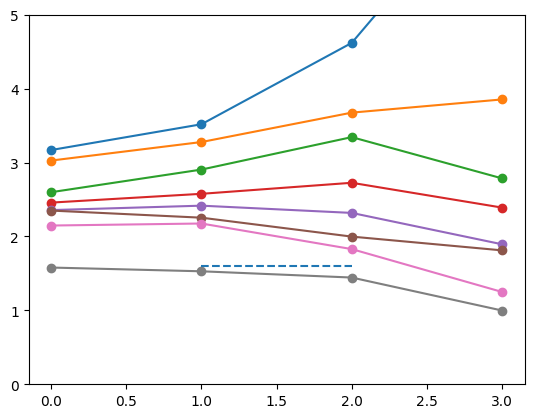

In [147]:
plt.plot( -np.log(eigvals)/at, marker='o' )
plt.hlines( 1.6, 1.0, 2.0, ls='dashed' )
plt.ylim( 0, 5 )

In [148]:
Nf

2

In [48]:
eigvals_ = []
for t in range(1,tcut):
    sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    matMtrunc = (Vrebase.T@matM@Vrebase)[-nops2:,-nops2:]
    matMtrunc = (matM)[-nops2:,-nops2:]
    eigval, eigvec = np.linalg.eigh(matMtrunc)
    eigvals_.append( eigval )

eigvals = np.array(eigvals_)
-np.log(eigvals)/at

array([[3.63825264, 3.22287576, 3.02932091, 2.60469205, 2.56873487,
        2.44309915, 2.35121803, 2.1485706 , 1.65728611],
       [4.34736408, 3.43964739, 3.10475597, 2.84426094, 2.5645049 ,
        2.41677536, 2.21296632, 2.14553763, 1.55922689],
       [6.86926971, 4.49040095, 3.8651995 , 3.0252295 , 2.54210809,
        2.15494038, 1.96171591, 1.48457432, 1.33829279]])

In [49]:
eigvals

array([[0.48304255, 0.52488549, 0.54560272, 0.59396291, 0.59824975,
        0.61347251, 0.62485003, 0.65069509, 0.71787687],
       [0.41917247, 0.50261567, 0.53743299, 0.56617493, 0.59875608,
        0.61671081, 0.64236843, 0.65108992, 0.73209472],
       [0.25312953, 0.40735095, 0.46160769, 0.54604936, 0.60144414,
        0.64986666, 0.67547226, 0.74310727, 0.765169  ]])

(0.0, 5.0)

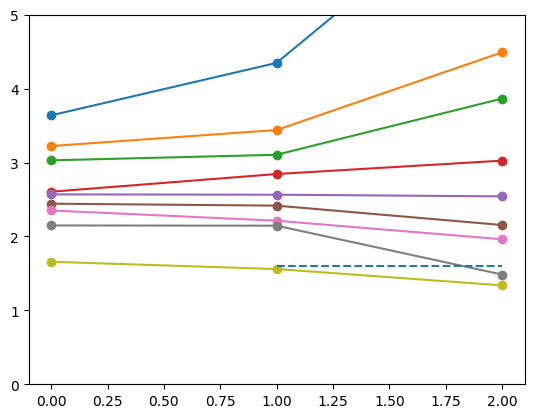

In [54]:
plt.plot( -np.log(eigvals)/at, marker='o' )

# plt.hlines( np.sqrt(2), 1.0, 2.0, ls='dashed' )
plt.hlines( 1.6, 1.0, 2.0, ls='dashed' )

plt.ylim( 0, 5 )

In [51]:
def get_eigvals( conn ):
    conn, dummy = zero_noise( conn, conn )
    matC1 = np.array(np.split( conn, nops, axis=0 ))[:nops1,:nops1]
    matC = np.transpose(matC1, (-1, 0, -2))
    matCT = np.transpose(matC, (0, 2, 1))
    matCA = 0.5*(matC+matCT)

    t=trebase
    sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    eigval, eigvec = np.linalg.eigh(matM)
    Vrebase=eigvec

    eigvals_ = []
    for t in range(1,tcut):
        sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
        matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
        matMtrunc = (Vrebase.T@matM@Vrebase)[-nops2:,-nops2:]
        eigval, eigvec = np.linalg.eigh(matMtrunc)
        eigvals_.append( eigval )
    eigvals = np.array(eigvals_)

    return -np.log(eigvals)/at

In [52]:
def gevp(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    return get_eigvals( conn )
    # matC1 = np.array(np.split( conn, nops, axis=0 ))[:nops1,:nops1]
    # matC = np.transpose(matC1, (-1, 0, -2))
    # matCT = np.transpose(matC, (0, 2, 1))
    # matCA = 0.5*(matC+matCT)

    # t=trebase
    # sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    # matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    # eigval, eigvec = np.linalg.eigh(matM)
    # Vrebase=eigvec

    # eigvals_ = []
    # for t in range(1,tcut):
    #     sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
    #     matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
    #     matMtrunc = (Vrebase.T@matM@Vrebase)[-nops2:,-nops2:]
    #     eigval, eigvec = np.linalg.eigh(matMtrunc)
    #     eigvals_.append( eigval )
    # eigvals = np.array(eigvals_)

    # return -np.log(eigvals)/at

In [53]:
jk = Jackknife( corrs.shape[0], 1 )
jk.set( gevp, corrs )
jk.do_it()


KeyboardInterrupt



In [ ]:
xx = np.arange(1,tcut)*at
for i in range(nops2):
    plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}$")

plt.savefig( desc+"_gevpspectrum.pdf")

In [ ]:
def twostates( t, m0, A, Dm ):
    return m0 + A*np.exp(-Dm*t)

def onestate( t, m0 ):
    return m0

In [ ]:
i=nops2-1
plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

In [160]:
iop=nops2-1
fitm=1
fitM=2

xx2=xx[fitm:fitM+1]
yy2=jk.mean().T[iop][fitm:fitM+1]
dyy2=jk.err().T[iop][fitm:fitM+1]

opt1=sp.optimize.curve_fit( onestate, xx2, yy2, sigma=dyy2, absolute_sigma=True )

In [161]:
opt1

(array([1.49064859]), array([[0.00300945]]))

In [162]:
dyy2

array([0.06893416, 0.09059317], dtype=float32)

In [163]:
def gevp_fit(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    yy = get_eigvals( conn ).T
    # print(yy)

    yyy = yy[iop][fitm:fitM+1]
    # print(yyy)
    dyyy = dyy2

    opt = sp.optimize.curve_fit( onestate, xx2, yyy, sigma=dyyy, p0=opt1[0], absolute_sigma=True )
    # print(opt[0])
    # print(opt[0])

    return opt[0]

In [164]:
jk2 = Jackknife( corrs.shape[0], 1 )
jk2.set( gevp_fit, corrs )
jk2.do_it()

In [165]:
format_print_w_exact( np.sqrt(2.0), jk2.mean()[0], jk2.err()[0] )

'1.491(71): -1.070 sigma'

In [166]:
jk2.mean()

array([1.49064849])

In [167]:
onestate(xx, jk2.mean()[0] )

1.4906484857445101

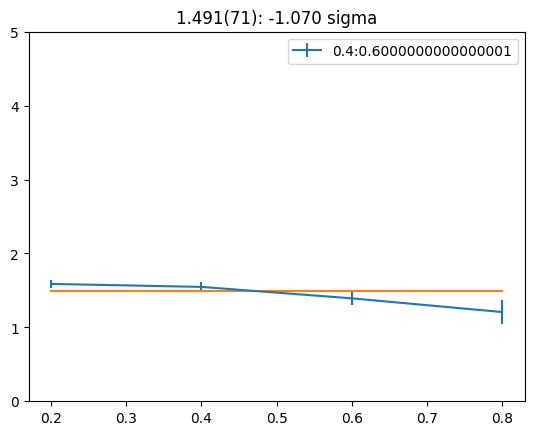

In [168]:
i=nops2-1
plt.errorbar( xx, jk.mean().T[i], jk.err().T[i], label=str((fitm+1)*float(at))+":"+str((fitM+1)*float(at)) )

plt.plot( xx, np.full(xx.shape[0], onestate(xx, jk2.mean()[0] )) )

plt.title(format_print_w_exact( np.sqrt(2.0), jk2.mean()[0], jk2.err()[0] ))
plt.legend()

plt.ylim(0.0,5.0)

plt.savefig( desc+"_fit_glue.pdf", bbox_inches="tight" )

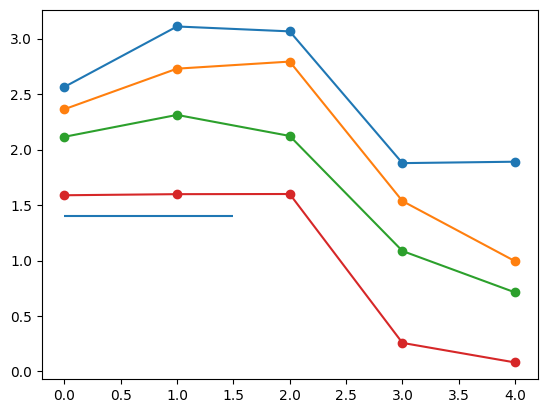

In [43]:
plt.plot( -np.log(eigvals)/at, marker='o' )
plt.hlines( 1.4, 0.0, 1.5 )

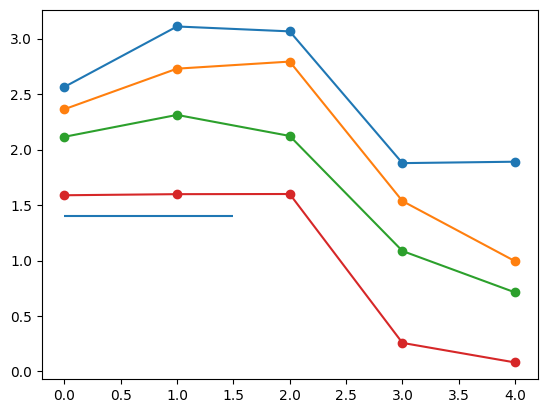

In [44]:
plt.plot( -np.log(eigvals)/at, marker='o' )
plt.hlines( 1.4, 0.0, 1.5 )

In [45]:
def gevp(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    matC1 = np.array(np.split( conn, nops, axis=0 ))
    matC = np.transpose(matC1, (-1, 0, -2))
    matCT = np.transpose(matC, (0, 2, 1))
    matCA = 0.5*(matC+matCT)

    eigvals_ = []
    for t in range(1,tcut):
        sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
        matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
        eigval, eigvec = np.linalg.eigh(matM)
        eigvals_.append( eigval )
    eigvals = np.array(eigvals_)

    return -np.log(eigvals)/at

In [27]:
nbins=40

In [28]:
jk = Jackknife( corr.shape[0], int( corr.shape[0]/nbins ) )
jk.set( gevp, corr )
jk.do_it()

ValueError: array split does not result in an equal division

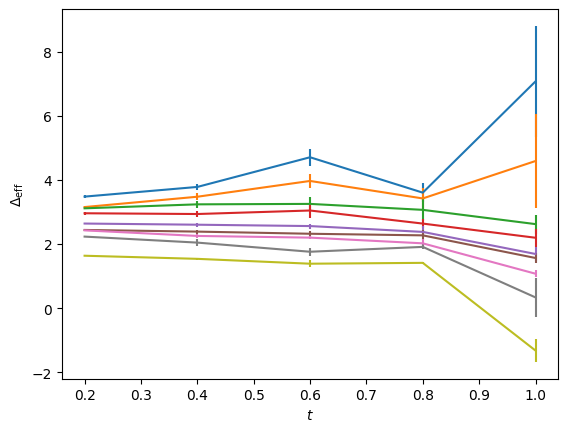

In [38]:
xx = np.arange(1,tcut)*at
for i in range(nops):
    plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

plt.xlabel("$t$")
plt.ylabel("$\\Delta_{\\rm eff}$")

plt.savefig("spectrum.pdf")

In [39]:
def twostates( t, m0, A, Dm ):
    return m0 + A*np.exp(-Dm*t)

def onestate( t, m0 ):
    return m0

<ErrorbarContainer object of 3 artists>

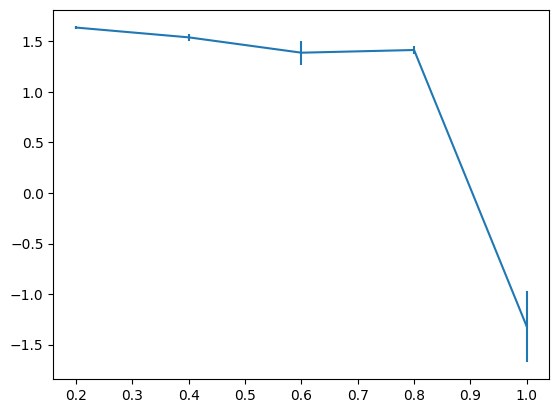

In [40]:
i=nops-1
plt.errorbar( xx, jk.mean().T[i], jk.err().T[i] )

In [39]:
iop=nops-1
fitm=2
fitM=4

xx2=xx[fitm:fitM]
yy2=jk.mean().T[iop][fitm:fitM]
dyy2=jk.err().T[iop][fitm:fitM]

opt1=sp.optimize.curve_fit( onestate, xx2, yy2, sigma=dyy2, absolute_sigma=True )

In [40]:
def gevp_fit(i, binsize, corr_):
    resmpld = np.delete(corr_, np.s_[i*binsize:(i+1)*binsize], axis=0)
    conn = np.mean(resmpld, axis=0)
    matC1 = np.array(np.split( conn, nops, axis=0 ))
    matC = np.transpose(matC1, (-1, 0, -2))
    matCT = np.transpose(matC, (0, 2, 1))
    matCA = 0.5*(matC+matCT)

    eigvals_ = []
    for t in range(1,tcut):
        sqrt_ct_inv = np.linalg.inv(sp.linalg.sqrtm(matCA[t]))
        matM = sqrt_ct_inv@matCA[t+dt]@sqrt_ct_inv
        eigval, eigvec = np.linalg.eigh(matM)
        eigvals_.append( eigval )
    eigvals = np.array(eigvals_)

    yy = (-np.log(eigvals)/at).T
    # print(yy)
    yyy = yy[iop][fitm:fitM]
    # print(yyy)
    dyyy = dyy2

    opt = sp.optimize.curve_fit( onestate, xx2, yyy, sigma=dyyy, p0=opt1[0], absolute_sigma=True )
    # print(opt[0])

    return opt[0]

In [41]:
jk2 = Jackknife( corr.shape[0], int( corr.shape[0]/nbins ) )
jk2.set( gevp_fit, corr )
jk2.do_it()

In [42]:
format_print_w_exact( np.sqrt(2.0), jk2.mean()[0], jk2.err()[0] )

'1.412(37): 0.064 sigma'